In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile, qasm3
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit.transpiler import generate_preset_pass_manager

First, let's define a simple quantum circuit. We will create an EPR pair and measure it.

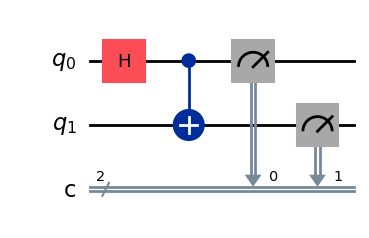

In [2]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0,1], [0,1])
qc.draw("mpl")

Let's see the corresponding OpenQASM.

In [3]:
print(qasm3.dumps(qc))

OPENQASM 3.0;
include "stdgates.inc";
bit[2] c;
qubit[2] q;
h q[0];
cx q[0], q[1];
c[0] = measure q[0];
c[1] = measure q[1];



Let's simulate the circuit classically too.

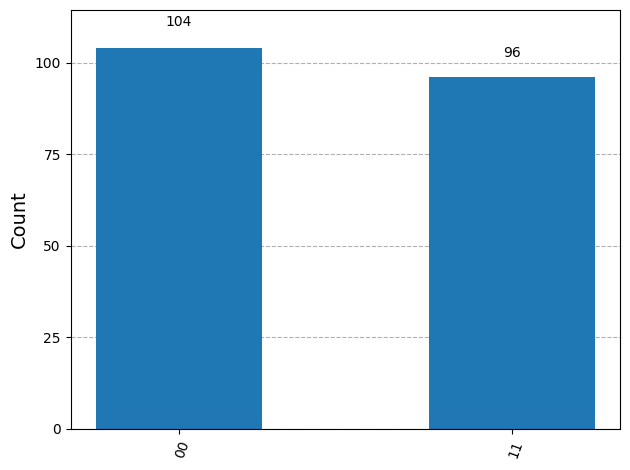

In [4]:
sim = AerSimulator()
result = sim.run(qc, shots=200).result()
counts = result.get_counts()
plot_histogram(counts)

Now, let's try a real machine. First, you need an API key. You can get one for free by signing up at the [IBM Quantum Platform](https://quantum.cloud.ibm.com/).

In [5]:
with open("api-key.txt") as keyfile:
  api_key = keyfile.read().strip()
QiskitRuntimeService.save_account(token=api_key, overwrite=True)

FileNotFoundError: [Errno 2] No such file or directory: 'api-key.txt'

Now we can write some boilerplate to send the circuit to a real machine. First, let's figure out which machine to use.

In [ ]:
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

Next, we need to compile the circuit down to a gate set that is compatible with our machine.

In [ ]:
transpiler = generate_preset_pass_manager(backend=backend, optimization_level=1)
transpiled_circuit = transpiler.run(qc)
transpiled_circuit.draw("mpl")

Now, we are ready to send the circuit to the machine.

In [ ]:
sampler = Sampler(mode=backend)
job = sampler.run([transpiled_circuit], shots=200)
result = job.result()

Finally, we create a histogram as before.

In [ ]:
counts = result[0].data.c.get_counts()
plot_histogram(counts)

Observe that transpilation is required; the machine does not accept the original circuit.

In [ ]:
sampler = Sampler(mode=backend)
job = sampler.run([qc], shots=200)
result = job.result()